In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

train_dir = "/content/drive/MyDrive/[AI] ANN/FACE_RAP001_K51"

img_width, img_height = 100, 100
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=True
)

print("Số class:", train_generator.num_classes)
print("Tên class:", train_generator.class_indices)

Found 1493 images belonging to 25 classes.
Số class: 25
Tên class: {'Bùi Khôi Nguyên': 0, 'Bùi Thành Luân': 1, 'Chu Đặng Lê Anh': 2, 'Hồ Công Minh Quân': 3, 'Hồ Thị Thanh Vy': 4, 'Hồ Văn Quý': 5, 'Huỳnh Châu Gia Phú': 6, 'Lê Nguyễn Quỳnh Như': 7, 'Nguyễn Gia Kiên': 8, 'Nguyễn Hoài An': 9, 'Nguyễn Ngọc Bảo Uyên': 10, 'Nguyễn Phương Mai': 11, 'Nguyễn Quốc Anh': 12, 'Nguyễn Đức Duy': 13, 'Nguyễn Đức Minh': 14, 'Phan Bá Phú Sĩ': 15, 'Phạm Kim Đạt': 16, 'Trần Hiếu Thiện': 17, 'Trần Hoài Trọng': 18, 'Trần Hồ Đức Bảo': 19, 'Trương Gia Kỳ': 20, 'Vũ Minh Khương': 21, 'trần trí khang': 22, 'Đỗ Nguyên Anh': 23, 'Đỗ Phan Thành Đạt': 24}


In [ ]:
model = Sequential([
    Conv2D(32,(3,3),activation = "relu",input_shape = (img_width,img_height,3)),
    MaxPooling2D(2,2),
    Conv2D(64,(3,3),activation = "relu"),
    MaxPooling2D(2,2),
    Conv2D(128,(3,3),activation = "relu"),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128,activation = "relu"),
    Dropout(0.5),
    Dense(25,activation = "softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer="adam",loss="categorical_crossentropy",metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,735,001 (6.62 MB)

 Trainable params: 1,735,001 (6.62 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(train_generator,epochs=10)


Epoch 1/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 985s 21s/step - accuracy: 0.0429 - loss: 3.2224
Epoch 2/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 38s 802ms/step - accuracy: 0.0951 - loss: 3.0850
Epoch 3/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 35s 730ms/step - accuracy: 0.1715 - loss: 2.8319
Epoch 4/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 37s 786ms/step - accuracy: 0.2599 - loss: 2.4341
Epoch 5/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 37s 774ms/step - accuracy: 0.3610 - loss: 2.0276
Epoch 6/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 38s 825ms/step - accuracy: 0.4601 - loss: 1.7826
Epoch 7/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 35s 748ms/step - accuracy: 0.5171 - loss: 1.5567
Epoch 8/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 37s 788ms/step - accuracy: 0.5834 - loss: 1.3248
Epoch 9/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 36s 760ms/step - accuracy: 0.6222 - loss: 1.2195
Epoch 10/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 38s 790ms/step - accuracy: 0.6557 - loss: 1.0829


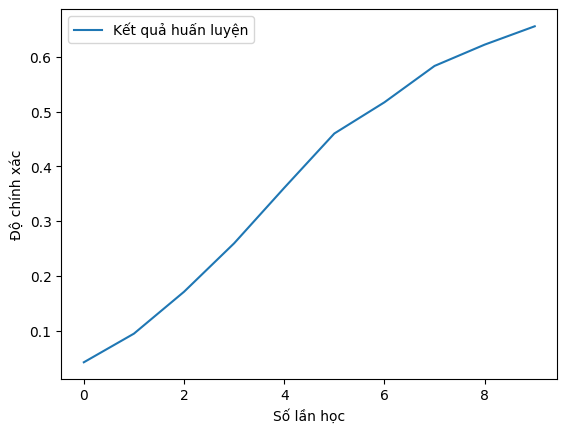

In [ ]:
plt.plot(history.history['accuracy'],label="Kết quả huấn luyện")
plt.ylabel('Độ chính xác')
plt.xlabel('Số lần học')
plt.legend()
plt.show()

In [ ]:
model.save("trained.h5")

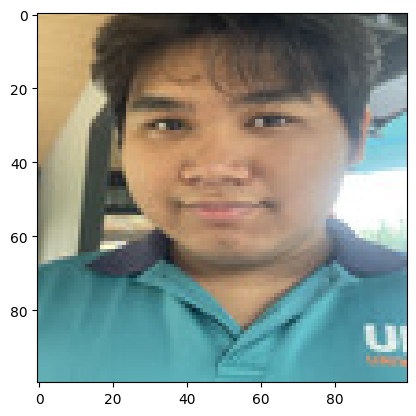

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 631ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Người tiên đoán:Đỗ Nguyên Anh


In [ ]:
import numpy as np
import tensorflow as tf
from keras.utils import load_img

model = tf.keras.models.load_model("trained.h5")
path = "/content/IMG_4683.jpg"
img = load_img(path,target_size=(100,100))
plt.imshow(img)
plt.show()
img=np.array(img)
img = img/255
img = img.reshape(1,100,100,3)
prediction = np.argmax(model.predict(img))
result = model.predict(img)
class_labels = {v: k for k, v in train_generator.class_indices.items()}
person_name = class_labels[prediction]
print(f"Người tiên đoán:{person_name}")